In [25]:
import matplotlib.pyplot as plt
import cv2
import torchinfo
from torch import nn
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
import fiftyone as fo
import fiftyone.zoo as foz

In [26]:
dataset = foz.load_zoo_dataset("coco-2014", split="train", max_samples=150)
session = fo.launch_app(dataset)

Found annotations at 'C:\Users\Andrea Korunoska\fiftyone\coco-2014\raw\instances_train2014.json'
Sufficient images already downloaded
Existing download of split 'train' is sufficient
Loading existing dataset 'coco-2014-train-150'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

cuda
2.5.1+cu121
True
12.1
1


In [28]:
# path = kagglehub.dataset_download("prasunroy/natural-images")
# print("Path to dataset files:", path)


#### Configurtations

In [29]:
CONFIGURATION = {
    'width': 320,
    'height': 240,
    'patch_w_h': 64,
    'max_shift': 16,
    'image_size': (320, 240),
    'learning_rate': 0.0005,
    'batch_size': 64,
    'epochs': 30000,
}

 ## Generate samples

In [30]:
class HomographyDataset(Dataset):
    def __init__(self, image_paths, img_size=(320, 240), patch_size=64, max_shift=16, samples_per_image=50, batch_size=1):
        self.image_paths = image_paths
        self.img_size = img_size
        self.patch_size = patch_size
        self.max_shift = max_shift
        self.samples_per_image = samples_per_image

        self.transform = transforms.Compose([
            transforms.Resize((img_size[1], img_size[0])),
            transforms.CenterCrop((img_size[1], img_size[0])),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ])

        image_folder = ImageFolder(root=image_paths, transform=self.transform)
        self.data = self.__preload_data(image_folder)
        self.loader = DataLoader(self, batch_size=batch_size, shuffle=True)

    def __preload_data(self, image_folder):
        loader = DataLoader(dataset=image_folder, batch_size=len(image_folder))
        data, _ = next(iter(loader))
        return data

    def __len__(self):
        return len(self.data)

    def pick_random_patch(self, image_w, image_h):
        safety = self.max_shift + 20
        x = np.random.randint(safety, image_w - self.patch_size - safety)
        y = np.random.randint(safety, image_h - self.patch_size - safety)
        return x, y

    def window_corners(self, x, y):
        return np.array([
            [x,                      y],
            [x + self.patch_size - 1, y],
            [x + self.patch_size - 1, y + self.patch_size - 1],
            [x,                      y + self.patch_size - 1],
        ], dtype=np.float32)

    def random_offsets(self):
        return np.random.randint(-self.max_shift, self.max_shift + 1, size=(4, 2)).astype(np.float32)

    def generate_sample(self, image):
        image_H, image_W = image.shape
        max_attempts = 10

        for attempt in range(max_attempts):
            x, y = self.pick_random_patch(image_W, image_H)
            base = self.window_corners(x, y)
            offsets = self.random_offsets()
            moved = base + offsets

            H_mat = cv2.getPerspectiveTransform(base, moved)

            if np.linalg.cond(H_mat) > 1e10:
                continue

            try:
                H_mat_inv = np.linalg.inv(H_mat)
            except np.linalg.LinAlgError:
                continue

            warped_image = cv2.warpPerspective(image, H_mat_inv, (image_W, image_H))
            patch = image[y:y + self.patch_size, x:x + self.patch_size]
            warped_patch = warped_image[y:y + self.patch_size, x:x + self.patch_size]
            two_channel = np.stack([patch, warped_patch], axis=0)

            return {
                "sample": torch.FloatTensor(two_channel),
                "offsets": torch.FloatTensor(offsets),
                "base_corners": torch.FloatTensor(base),
                "moved_corners": torch.FloatTensor(moved),
                "H_mat": torch.FloatTensor(H_mat),
                "image": image,
                "warped_image": warped_image,
            }

        raise RuntimeError(f"Could not generate a valid sample after {max_attempts} attempts.")

    def __getitem__(self, idx):
        img_tensor = self.data[idx]
        image_np = img_tensor.squeeze(0).numpy()  # (H, W)
        data = self.generate_sample(image_np)

        return (
            data['offsets'],                                       # (4, 2)
            data['base_corners'],                                  # (4, 2)
            data['moved_corners'],                                 # (4, 2)
            data['H_mat'],                                         # (3, 3)
            torch.FloatTensor(image_np).unsqueeze(0),             # (1, H, W)
            torch.FloatTensor(data['warped_image']).unsqueeze(0), # (1, H, W)
            data['sample'][0:1],                                   # (1, patch, patch)
            data['sample'][1:2],                                   # (1, patch, patch)
        )

In [31]:
dataset = HomographyDataset(
    image_paths=r'C:\Users\Andrea Korunoska\fiftyone\coco-2014\train',
    img_size=(CONFIGURATION['width'], CONFIGURATION['height']),
    patch_size=CONFIGURATION['patch_w_h'],
    max_shift=CONFIGURATION['max_shift'],
    batch_size=CONFIGURATION['batch_size']
)

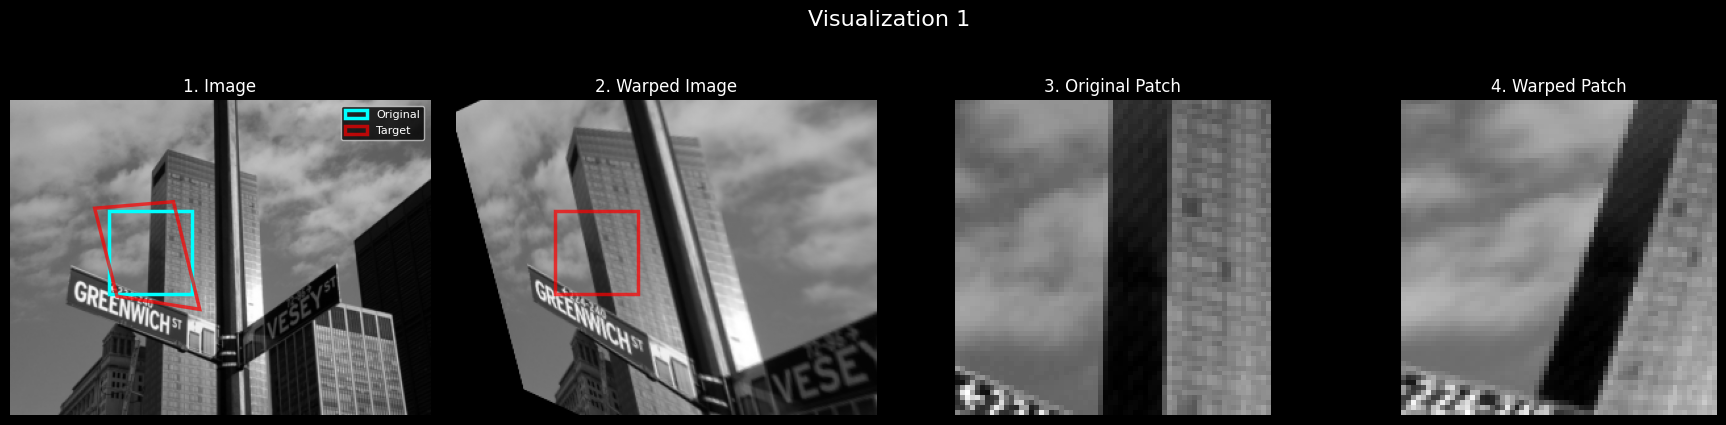

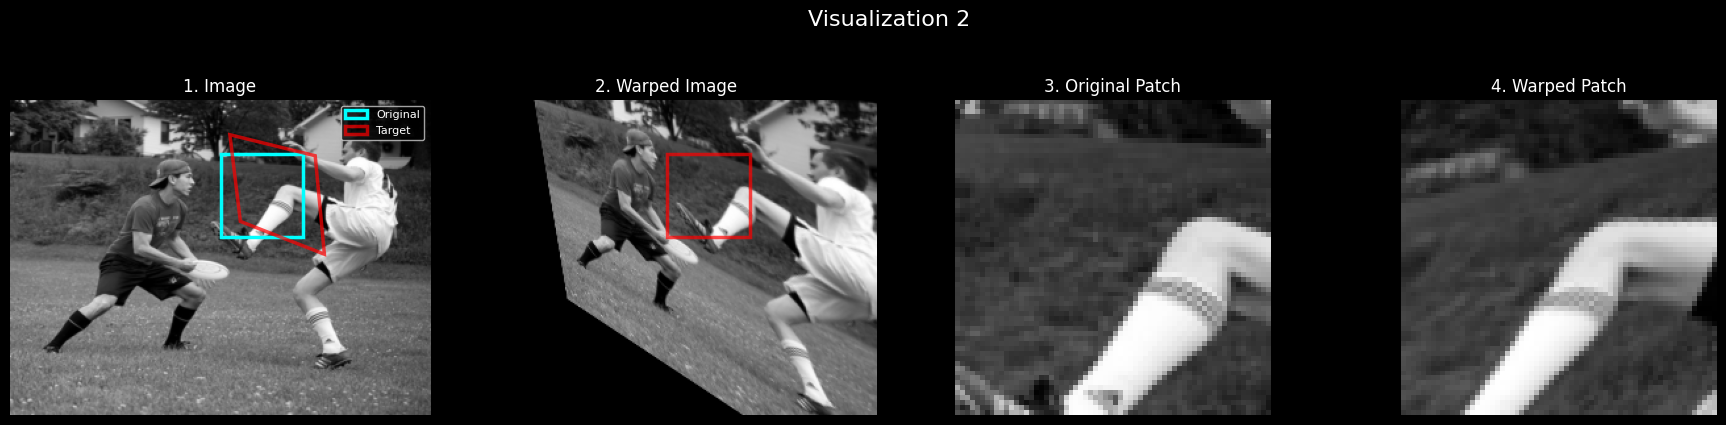

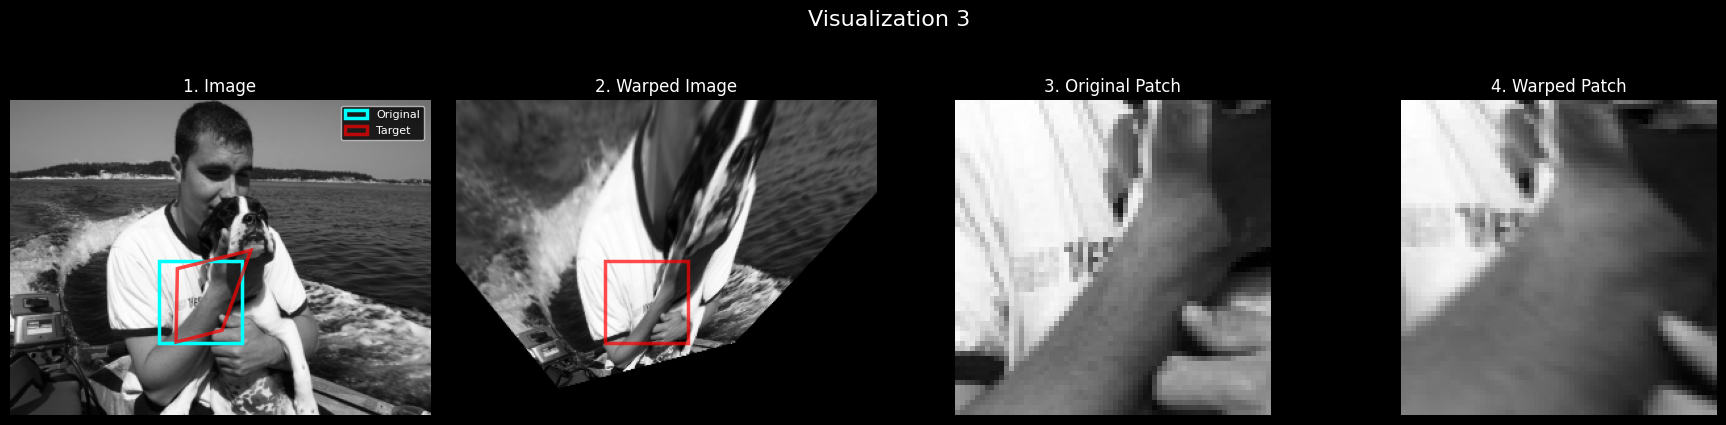

In [32]:
for n in range(3):
    offsets, pts, pts_aug, H_mat, img, img_warp, patch, patch_warp = next(iter(dataset.loader))

    # Undo normalization for display: x = (x_norm * 0.5) + 0.5
    img_np = img[0].squeeze(0).numpy() * 0.5 + 0.5        # (H, W)
    patch_np = patch[0].squeeze(0).numpy() * 0.5 + 0.5    # (patch, patch)
    patch_warp_np = patch_warp[0].squeeze(0).numpy() * 0.5 + 0.5

    # corners are already (x, y) so no swap needed for plotting
    corners_orig = pts[0].numpy()      # (4, 2) as (x, y)
    corners_moved = pts_aug[0].numpy() # (4, 2) as (x, y)

    # Re-warp full image for visualization using the forward homography
    H_forward = cv2.getPerspectiveTransform(
        corners_orig.astype(np.float32),
        corners_moved.astype(np.float32)
    )
    h, w = img_np.shape
    img_warped_vis = cv2.warpPerspective(img_np, H_forward, (w, h))

    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    axs[0].imshow(img_np, cmap="gray")
    axs[0].add_patch(plt.Polygon(corners_orig, fill=False, ec="cyan", lw=2.5, label="Original"))
    axs[0].add_patch(plt.Polygon(corners_moved, fill=False, ec="red", lw=2.5, label="Target", alpha=0.7))
    axs[0].set_title("1. Image", fontsize=12)
    axs[0].set_axis_off()
    axs[0].legend(loc='upper right', fontsize=8)

    axs[1].imshow(img_warped_vis, cmap="gray")
    axs[1].add_patch(plt.Polygon(corners_orig, fill=False, ec="red", lw=2.5, alpha=0.7))
    axs[1].set_title("2. Warped Image", fontsize=12)
    axs[1].set_axis_off()

    axs[2].imshow(patch_np, cmap="gray")
    axs[2].set_title("3. Original Patch", fontsize=12)
    axs[2].set_axis_off()

    axs[3].imshow(patch_warp_np, cmap="gray")
    axs[3].set_title("4. Warped Patch", fontsize=12)
    axs[3].set_axis_off()

    plt.suptitle(f'Visualization {n+1}', fontsize=16, y=1.05)
    plt.tight_layout()
    plt.show()

### Neural network

In [33]:
class ResNetBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.convolution1 = nn.Conv2d(input_channels, output_channels, kernel_size=3, padding=1, bias=False)
        self.normalization1 = nn.BatchNorm2d(output_channels)
        self.convolution2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=1, bias=False)
        self.normalization2 = nn.BatchNorm2d(output_channels)

        if input_channels != output_channels:
            self.identity = nn.Conv2d(input_channels, output_channels, kernel_size=1, stride=1)
        else:
            self.identity = nn.Identity()

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.identity(x)
        out = self.convolution1(x)
        out = self.normalization1(out)
        out = self.relu(out)
        out = self.convolution2(out)
        out = self.normalization2(out)
        out += identity
        out = self.relu(out)
        return out

In [34]:
class HomographyBody(nn.Module):
    def __init__(self, input_channels):
        super().__init__()

        self.body = nn.Sequential(
            ResNetBlock(input_channels, 64),
            ResNetBlock(64, 64),
            nn.MaxPool2d(2),

            ResNetBlock(64, 64),
            ResNetBlock(64, 64),
            nn.MaxPool2d(2),

            ResNetBlock(64, 128),
            ResNetBlock(128, 128),
            nn.MaxPool2d(2),

            ResNetBlock(128, 128),
            ResNetBlock(128, 128),

            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.body(x)

#### Regression

In [35]:
class RegressionHead(nn.Module):
    def __init__(self, input_channels=2, out_dim=8):
        super().__init__()
        self.body = HomographyBody(input_channels)
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x: torch.Tensor):
        features = self.body(x)
        offsets = self.fc(features)
        return offsets  # (B, 8)

In [36]:
regression = RegressionHead().to(device)
regression_optimizer = torch.optim.Adam(regression.parameters(), lr=CONFIGURATION['learning_rate'])
regression_loss = nn.MSELoss()

torchinfo.summary(regression, [1, 2, 64, 64], depth=4)

Layer (type:depth-idx)                   Output Shape              Param #
RegressionHead                           [1, 8]                    --
├─HomographyBody: 1-1                    [1, 512]                  --
│    └─Sequential: 2-1                   [1, 512]                  --
│    │    └─ResNetBlock: 3-1             [1, 64, 64, 64]           --
│    │    │    └─Conv2d: 4-1             [1, 64, 64, 64]           192
│    │    │    └─Conv2d: 4-2             [1, 64, 64, 64]           1,152
│    │    │    └─BatchNorm2d: 4-3        [1, 64, 64, 64]           128
│    │    │    └─ReLU: 4-4               [1, 64, 64, 64]           --
│    │    │    └─Conv2d: 4-5             [1, 64, 64, 64]           36,864
│    │    │    └─BatchNorm2d: 4-6        [1, 64, 64, 64]           128
│    │    │    └─ReLU: 4-7               [1, 64, 64, 64]           --
│    │    └─ResNetBlock: 3-2             [1, 64, 64, 64]           --
│    │    │    └─Identity: 4-8           [1, 64, 64, 64]           --
│    

#### Classification

In [37]:
class ClassificationHead(nn.Module):
    def __init__(self, input_channels=2, num_classes=33, out_dim=8):
        super().__init__()
        self.body = HomographyBody(input_channels)
        self.fc = nn.Linear(512, num_classes * out_dim)
        self.num_classes = num_classes
        self.out_dim = out_dim

    def forward(self, x: torch.Tensor):
        features = self.body(x)
        x = self.fc(features)
        x = x.view(-1, self.num_classes, self.out_dim)  # (B, 21, 8)
        return x

In [38]:
classification = ClassificationHead().to(device)
classification_optimizer = torch.optim.Adam(classification.parameters(), lr=CONFIGURATION['learning_rate'])
classification_loss = nn.CrossEntropyLoss()

torchinfo.summary(classification, [1, 2, 64, 64], depth=4)

Layer (type:depth-idx)                   Output Shape              Param #
ClassificationHead                       [1, 33, 8]                --
├─HomographyBody: 1-1                    [1, 512]                  --
│    └─Sequential: 2-1                   [1, 512]                  --
│    │    └─ResNetBlock: 3-1             [1, 64, 64, 64]           --
│    │    │    └─Conv2d: 4-1             [1, 64, 64, 64]           192
│    │    │    └─Conv2d: 4-2             [1, 64, 64, 64]           1,152
│    │    │    └─BatchNorm2d: 4-3        [1, 64, 64, 64]           128
│    │    │    └─ReLU: 4-4               [1, 64, 64, 64]           --
│    │    │    └─Conv2d: 4-5             [1, 64, 64, 64]           36,864
│    │    │    └─BatchNorm2d: 4-6        [1, 64, 64, 64]           128
│    │    │    └─ReLU: 4-7               [1, 64, 64, 64]           --
│    │    └─ResNetBlock: 3-2             [1, 64, 64, 64]           --
│    │    │    └─Identity: 4-8           [1, 64, 64, 64]           --
│    

### Train model


In [40]:
def train_model(model, model_optimizer, model_loss, model_name):
    scheduler = torch.optim.lr_scheduler.StepLR(model_optimizer, step_size=5000, gamma=0.5)
    model_train_loss = []

    is_classification = isinstance(model, ClassificationHead)

    for epoch in range(CONFIGURATION['epochs']):
        model.train()
        batch_losses = []

        for offsets, pts, pts_aug, H_mat, img, img_warp, patch, patch_warp in dataset.loader:
            input = torch.cat([patch, patch_warp], dim=1).to(device)

            if is_classification:
                target = (offsets.view(-1, 8) + CONFIGURATION['max_shift']).long().to(device)
            else:
                target = offsets.view(-1, 8).float().to(device)

            model_optimizer.zero_grad()
            output = model(input)
            loss = model_loss(output, target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            model_optimizer.step()
            batch_losses.append(loss.item())

        scheduler.step()
        epoch_loss = sum(batch_losses) / len(batch_losses)
        model_train_loss.append(epoch_loss)
        print(f"Epoch: {epoch+1}/{CONFIGURATION['epochs']}, Train Loss: {epoch_loss:.6f}")

    torch.save(model, f"models/{model_name}.pt")
    return model_train_loss

In [41]:
regression_loss_history = train_model(regression, regression_optimizer, regression_loss, "regression")

Epoch: 1/30000, Train Loss: 120.111664
Epoch: 2/30000, Train Loss: 94.750898
Epoch: 3/30000, Train Loss: 90.120092
Epoch: 4/30000, Train Loss: 89.572294
Epoch: 5/30000, Train Loss: 88.664973
Epoch: 6/30000, Train Loss: 92.435951
Epoch: 7/30000, Train Loss: 94.015757
Epoch: 8/30000, Train Loss: 100.806872
Epoch: 9/30000, Train Loss: 93.812678
Epoch: 10/30000, Train Loss: 87.511017
Epoch: 11/30000, Train Loss: 91.083623
Epoch: 12/30000, Train Loss: 96.521144
Epoch: 13/30000, Train Loss: 90.366376
Epoch: 14/30000, Train Loss: 89.945712
Epoch: 15/30000, Train Loss: 91.583356
Epoch: 16/30000, Train Loss: 90.709231
Epoch: 17/30000, Train Loss: 89.745730
Epoch: 18/30000, Train Loss: 92.861430
Epoch: 19/30000, Train Loss: 92.132284
Epoch: 20/30000, Train Loss: 88.979118
Epoch: 21/30000, Train Loss: 91.159223
Epoch: 22/30000, Train Loss: 91.049988
Epoch: 23/30000, Train Loss: 87.740448
Epoch: 24/30000, Train Loss: 86.787259
Epoch: 25/30000, Train Loss: 91.234281
Epoch: 26/30000, Train Loss: 90.

In [42]:
classification_loss_history = train_model(classification, classification_optimizer, classification_loss, "classification")

In [43]:
# Load saved regression model
regression = torch.load("models/regression.pt", map_location=device)
## todo classification fix and test
regression.eval()
print("Model loaded successfully")
print("Type:", type(regression))

Model loaded successfully
Type: <class '__main__.RegressionHead'>


C:\Users\Andrea Korunoska\AppData\Local\Temp\ipykernel_4052\3027965402.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  regression = torch.load("models/regression.pt", ma

### Visualize loss and prediction

In [44]:
def plot_loss(loss_list, window):
    loss = np.array(loss_list, dtype=float)

    if len(loss) >= window:
        shape = (loss.size - window + 1, window)
        strides = (loss.strides[0], loss.strides[0])
        windows = np.lib.stride_tricks.as_strided(loss, shape=shape, strides=strides)
        smooth = windows.mean(axis=1)
    else:
        smooth = loss

    plt.figure(figsize=(8,4))
    plt.plot(loss, label="Raw loss")
    plt.plot(range(window-1, window-1 + len(smooth)), smooth, label=f"Smoothed (window={window})")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


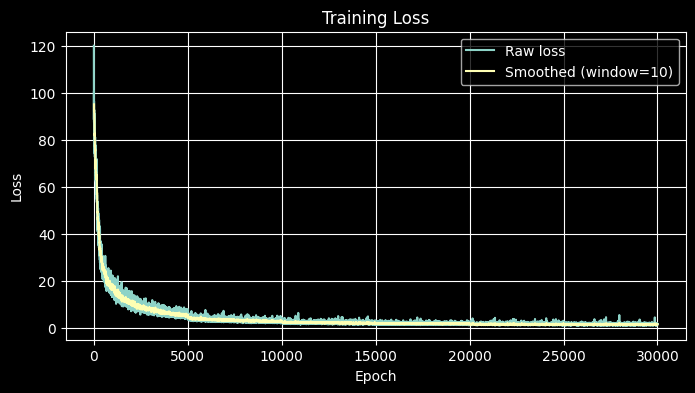

In [45]:
plot_loss(regression_loss_history, 10)

In [46]:
plot_loss(classification_loss_history, 10)

In [47]:
def visualize_homography_prediction(dataset, model, device, n=5):
    model.eval()

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))

    for ax in axes:
        offsets, pts, pts_aug, H_mat, img, img_warp, patch, patch_warp = next(iter(dataset.loader))

        img_np = img[0].squeeze(0).numpy() * 0.5 + 0.5

        original_xy = pts[0].numpy()
        target_xy   = pts_aug[0].numpy()

        with torch.no_grad():
            inp = torch.cat([patch, patch_warp], dim=1).to(device)

            if isinstance(model, ClassificationHead):
                output = model(inp)  # (B, 33, 8)
                pred_class = output[0].argmax(dim=0)  # (8,)
                pred_offsets = (pred_class.float() - CONFIGURATION['max_shift']).cpu()
            else:
                pred_offsets = model(inp)[0].cpu()  # (8,)

        pred_xy = (pts[0].view(8) + pred_offsets).view(4, 2).numpy()

        ax.imshow(img_np, cmap="gray")
        ax.add_patch(plt.Polygon(original_xy, fill=False, ec="cyan",   lw=2.5, label="Original"))
        ax.add_patch(plt.Polygon(target_xy,   fill=False, ec="red",    lw=2.5, label="Target"))
        ax.add_patch(plt.Polygon(pred_xy,     fill=False, ec="yellow", lw=2.5, label="Predicted"))
        ax.set_axis_off()

    axes[0].legend(loc="upper right", fontsize=8)
    plt.suptitle(f"{'Classification' if isinstance(model, ClassificationHead) else 'Regression'} predictions", fontsize=14)
    plt.tight_layout()
    plt.show()

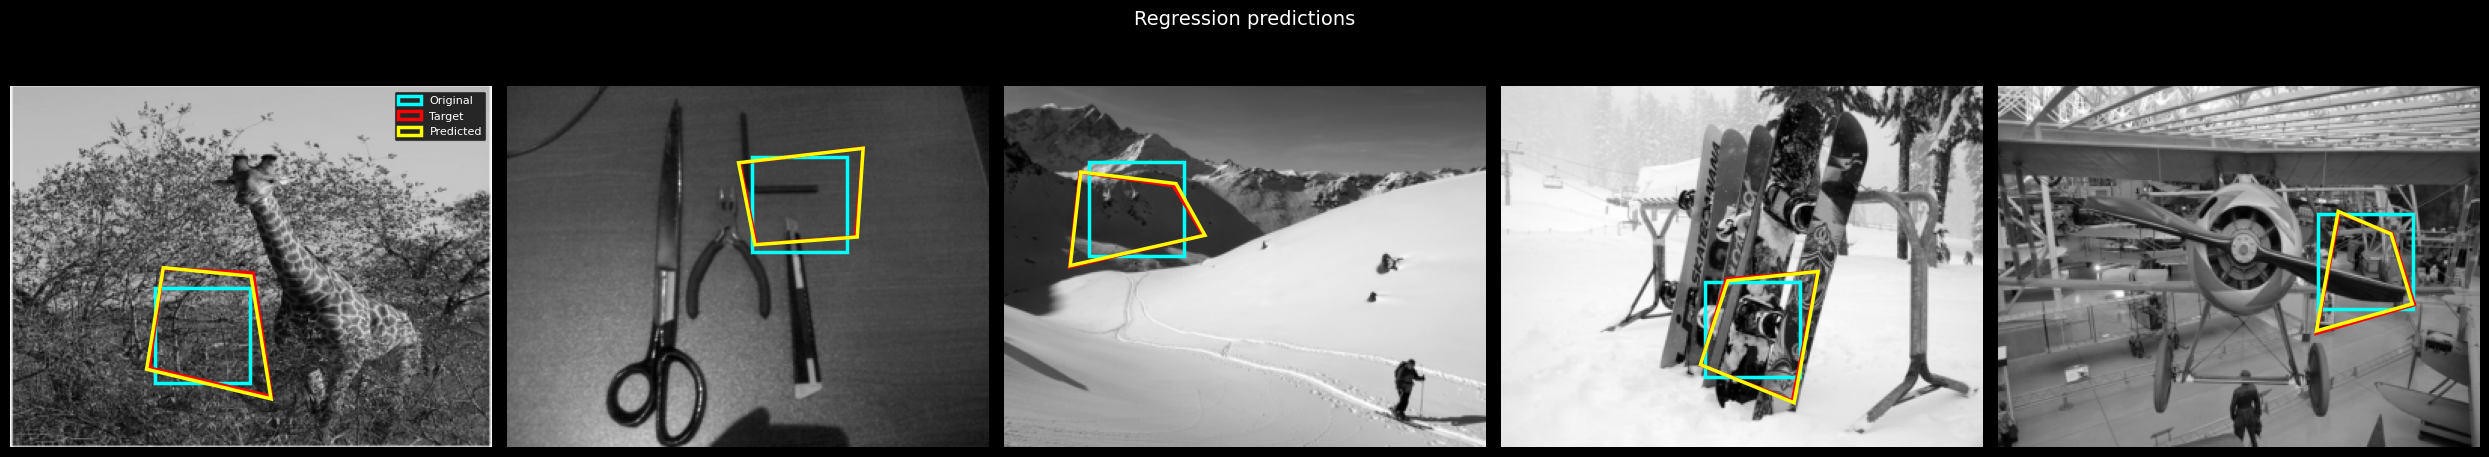

In [48]:
visualize_homography_prediction(dataset, regression, device)

In [49]:
visualize_homography_prediction(dataset, classification, device)
